# 79 — X/length anchoring audit

This notebook targets the x/length anchor model directly.

It asks two concrete questions:

- Does changing the x measurement weighting materially improve final parity?
- Does changing the constant y/length anchor improve FL in a way that is still faithful to MATLAB endpoint geometry?

In [1]:
from __future__ import annotations

import os
import subprocess
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SCRIPT = ROOT / 'scripts' / 'evaluate_x_length_anchoring.py'
OUT = ROOT / 'results' / 'notebook79_x_length_anchoring'

assert SCRIPT.exists(), SCRIPT
OUT.mkdir(parents=True, exist_ok=True)
print('Project root:', ROOT)
print('Script:', SCRIPT)
print('Output directory:', OUT)

Project root: /Users/grosbedou/PycharmProjects/NDORMS
Script: /Users/grosbedou/PycharmProjects/NDORMS/scripts/evaluate_x_length_anchoring.py
Output directory: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook79_x_length_anchoring


In [2]:
env = dict(os.environ)
env.setdefault('MPLCONFIGDIR', '/private/tmp/matplotlib')
subprocess.run([sys.executable, str(SCRIPT)], cwd=ROOT, env=env, check=True)

# Notebook 79 — x/length anchoring audit

Aligned 2666 MATLAB/Python samples with Python offset 1.

This notebook targets the x/length anchor model directly while reusing notebook 77's saved KLT prior, affines, TimTrack alpha, and aponeurosis lines.

## Main findings

- Sweeping the x measurement variance changes final FL only trivially. Across the tested range 10 to 1000, FL RMSE only moves from 2.0105 to 2.0119 mm, while forward-state x bias stays near 1.36–1.43 px.
- Sweeping the constant fixed superficial y anchor changes final FL much more. In the tested range, FL RMSE improves from 2.0117 mm at dy=0 to 1.9174 mm at dy=60 px.
- That apparent FL improvement is not a faithful parity improvement: at the same dy=60 px point, final-end endpoint geometry gets much worse. `fas_x_end` x_sup RMSE grows from 5.95 px to 123.69 px, and x_deep RMSE grows from 25.80 px to 144.63 px.
- Using MATLAB's own frame-0 fixed-y anchor does not help. The MATLAB-frame0-y variant gives FL RMSE 2.0141 mm, n

CompletedProcess(args=['/Users/grosbedou/PycharmProjects/NDORMS/.venv/bin/python', '/Users/grosbedou/PycharmProjects/NDORMS/scripts/evaluate_x_length_anchoring.py'], returncode=0)

In [3]:
display(Markdown((OUT / 'notebook79_summary.md').read_text()))

x_var = pd.read_csv(OUT / 'x_measurement_variance_sweep.csv')
y_anchor = pd.read_csv(OUT / 'fixed_y_anchor_sweep.csv')
named = pd.read_csv(OUT / 'named_x_length_variants.csv')

display(Markdown('## X-measurement variance sweep'))
display(x_var)

display(Markdown('## Fixed-y anchor sweep'))
display(y_anchor)

display(Markdown('## Named anchor variants'))
display(named)

# Notebook 79 — x/length anchoring audit

Aligned 2666 MATLAB/Python samples with Python offset 1.

This notebook targets the x/length anchor model directly while reusing notebook 77's saved KLT prior, affines, TimTrack alpha, and aponeurosis lines.

## Main findings

- Sweeping the x measurement variance changes final FL only trivially. Across the tested range 10 to 1000, FL RMSE only moves from 2.0105 to 2.0119 mm, while forward-state x bias stays near 1.36–1.43 px.
- Sweeping the constant fixed superficial y anchor changes final FL much more. In the tested range, FL RMSE improves from 2.0117 mm at dy=0 to 1.9174 mm at dy=60 px.
- That apparent FL improvement is not a faithful parity improvement: at the same dy=60 px point, final-end endpoint geometry gets much worse. `fas_x_end` x_sup RMSE grows from 5.95 px to 123.69 px, and x_deep RMSE grows from 25.80 px to 144.63 px.
- Using MATLAB's own frame-0 fixed-y anchor does not help. The MATLAB-frame0-y variant gives FL RMSE 2.0141 mm, not better than baseline.

## Audit cross-check

- The crucial unresolved difference is still final-end geometry (`fas_x_end` / `fas_y_end`), especially the x coordinates. Earlier parity audits already showed those endpoint RMSEs were large, and notebook 79 confirms that simple anchor tweaks only trade FL against endpoint correctness.
- I do not see another must-use MATLAB function being ignored that obviously outranks this issue. The main contract fields for the current mismatch are already in play: `X_plus`, `X_minus`, `fas_x`, `fas_y`, `fas_x_end`, `fas_y_end`, and `alpha`.
- One lower-priority contract field that is still not explicitly mirrored as a named output is MATLAB `Fascicle.A`. It is worth keeping on the checklist, but nothing in these anchor sweeps suggests it is the dominant blocker for current FL parity.

## Interpretation

- The remaining FL gap is not primarily a scalar tuning problem in the x measurement update.
- The constant-y anchor is powerful enough to improve FL, but only by compensating in a way that breaks endpoint geometry. That makes it a diagnostic clue, not a production fix.
- The next useful direction is to inspect how the final fascicle end segment is reconstructed from `[x_sup, alpha]` and the aponeurosis lines, rather than continuing to tune scalar variances.

- X-variance sweep CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook79_x_length_anchoring/x_measurement_variance_sweep.csv`
- Fixed-y sweep CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook79_x_length_anchoring/fixed_y_anchor_sweep.csv`
- Named variant CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook79_x_length_anchoring/named_x_length_variants.csv`
- Sweep plot: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook79_x_length_anchoring/x_length_anchor_sweeps.png`


## X-measurement variance sweep

,x_measurement_variance,FL_bias,FL_mae,FL_rmse,ANG_bias,ANG_mae,ANG_rmse,PEN_bias,PEN_mae,PEN_rmse,forward_x_bias,forward_x_mae,forward_x_rmse
0,10.0,-1.807589,1.926967,2.010478,1.034020,1.073846,1.166109,0.965913,1.008359,1.094590,1.434748,5.287752,6.701471
1,25.0,-1.808168,1.927532,2.011053,1.034021,1.073847,1.166111,0.965914,1.008361,1.094592,1.425146,5.077839,6.429478
2,50.0,-1.808535,1.927883,2.011412,1.034021,1.073847,1.166110,0.965914,1.008360,1.094591,1.404522,4.948843,6.252982
3,75.0,-1.808696,1.928034,2.011567,1.034020,1.073847,1.166111,0.965913,1.008360,1.094592,1.390227,4.895198,6.173356
4,100.0,-1.808792,1.928121,2.011657,1.034019,1.073846,1.166109,0.965912,1.008359,1.094590,1.380744,4.868117,6.129492
5,150.0,-1.808896,1.928214,2.011752,1.034021,1.073847,1.166111,0.965914,1.008360,1.094592,1.369088,4.846887,6.086698
6,200.0,-1.808956,1.928266,2.011805,1.034021,1.073847,1.166110,0.965913,1.008360,1.094591,1.363357,4.844436,6.070920
7,300.0,-1.809018,1.928318,2.011856,1.034021,1.073847,1.166112,0.965914,1.008360,1.094593,1.359397,4.859124,6.070105
8,500.0,-1.809073,1.928361,2.011895,1.034020,1.073846,1.166110,0.965913,1.008359,1.094591,1.364338,4.912801,6.106778
9,1000.0,-1.809125,1.928398,2.011920,1.034021,1.073846,1.166110,0.965913,1.008359,1.094591,1.392103,5.055436,6.217726


## Fixed-y anchor sweep

,fixed_y_offset_px,fixed_superficial_y_px,FL_bias,FL_mae,FL_rmse,ANG_bias,ANG_mae,ANG_rmse,PEN_bias,PEN_mae,...,end_x_sup_rmse,end_y_sup_bias,end_y_sup_mae,end_y_sup_rmse,end_x_deep_bias,end_x_deep_mae,end_x_deep_rmse,end_y_deep_bias,end_y_deep_mae,end_y_deep_rmse
0,-20.0,35.872883,-1.844243,1.962909,2.047159,1.034020,1.073847,1.166110,0.965913,1.008360,...,39.433753,0.119717,0.458471,0.589811,-16.285455,16.317351,20.355992,0.082692,0.622307,0.865576
1,-10.0,45.872883,-1.826406,1.945421,2.029074,1.034019,1.073846,1.166111,0.965912,1.008359,...,19.732342,0.518695,0.615752,0.734859,3.625870,9.112957,11.844290,0.557011,0.706627,0.955197
2,-5.0,50.872883,-1.817579,1.936754,2.020289,1.034019,1.073846,1.166107,0.965912,1.008359,...,10.504145,0.718459,0.765348,0.875085,13.608966,15.322484,17.389507,0.794132,0.868062,1.088285
3,0.0,55.872883,-1.808792,1.928121,2.011657,1.034019,1.073846,1.166109,0.965912,1.008359,...,5.948635,0.918516,0.938071,1.038384,23.613672,24.195752,25.801037,1.031368,1.070196,1.258018
4,5.0,60.872883,-1.800042,1.919516,2.003172,1.034020,1.073845,1.166110,0.965912,1.008358,...,12.884800,1.118943,1.123366,1.215665,33.642296,33.770252,35.097215,1.268836,1.289001,1.451584
5,10.0,65.872883,-1.791319,1.910928,1.994827,1.034024,1.073851,1.166117,0.965917,1.008364,...,22.448825,1.319805,1.321199,1.401840,43.696138,43.696138,44.749779,1.506639,1.521409,1.660756
6,20.0,75.872883,-1.773905,1.893745,1.978504,1.034023,1.073849,1.166115,0.965916,1.008362,...,42.525237,1.722889,1.722901,1.790346,63.873661,63.873661,64.530749,1.983479,1.993507,2.107599
7,30.0,85.872883,-1.756465,1.876503,1.962633,1.034023,1.073849,1.166117,0.965916,1.008362,...,62.899053,2.127200,2.127200,2.191188,84.099890,84.099890,84.594387,2.461635,2.469525,2.576409
8,40.0,95.872883,-1.738928,1.859210,1.947174,1.034024,1.073848,1.166115,0.965917,1.008362,...,83.293339,2.531189,2.531189,2.597828,104.279663,104.279663,104.712884,2.939853,2.946240,3.056992
9,50.0,105.872883,-1.721204,1.841925,1.932105,1.034026,1.073852,1.166119,0.965919,1.008365,...,103.570878,2.933420,2.933420,3.006394,124.325224,124.325224,124.742738,3.416998,3.422009,3.544269


## Named anchor variants

,variant,x_measurement_variance,fixed_superficial_y_px,fixed_y_offset_from_baseline_px,FL_bias,FL_mae,FL_rmse,ANG_bias,ANG_mae,ANG_rmse,PEN_bias,PEN_mae,PEN_rmse,end_x_sup_bias,end_x_sup_mae,end_x_sup_rmse,end_x_deep_bias,end_x_deep_mae,end_x_deep_rmse
0,baseline,100.0,55.872883,0.000000,-1.808792,1.928121,2.011657,1.034019,1.073846,1.166109,0.965912,1.008359,1.094590,1.084837,4.864974,5.948635,23.613672,24.195752,25.801037
1,best_x_variance_for_FL,10.0,55.872883,0.000000,-1.807589,1.926967,2.010478,1.034020,1.073846,1.166109,0.965913,1.008359,1.094590,0.987184,5.137294,6.549534,23.503363,24.089413,25.838216
2,matlab_frame0_fixed_y,100.0,54.418755,-1.454128,-1.811343,1.930626,2.014150,1.034020,1.073846,1.166109,0.965913,1.008359,1.094590,-1.853242,4.434651,6.004589,20.701644,21.496442,23.220591
3,best_fixed_y_for_FL_in_tested_range,100.0,115.872883,60.000000,-1.703203,1.824453,1.917380,1.034024,1.073850,1.166118,0.965917,1.008363,1.094598,122.761908,122.761908,123.692083,144.212548,144.212548,144.634707


## X/length anchor sweep plot

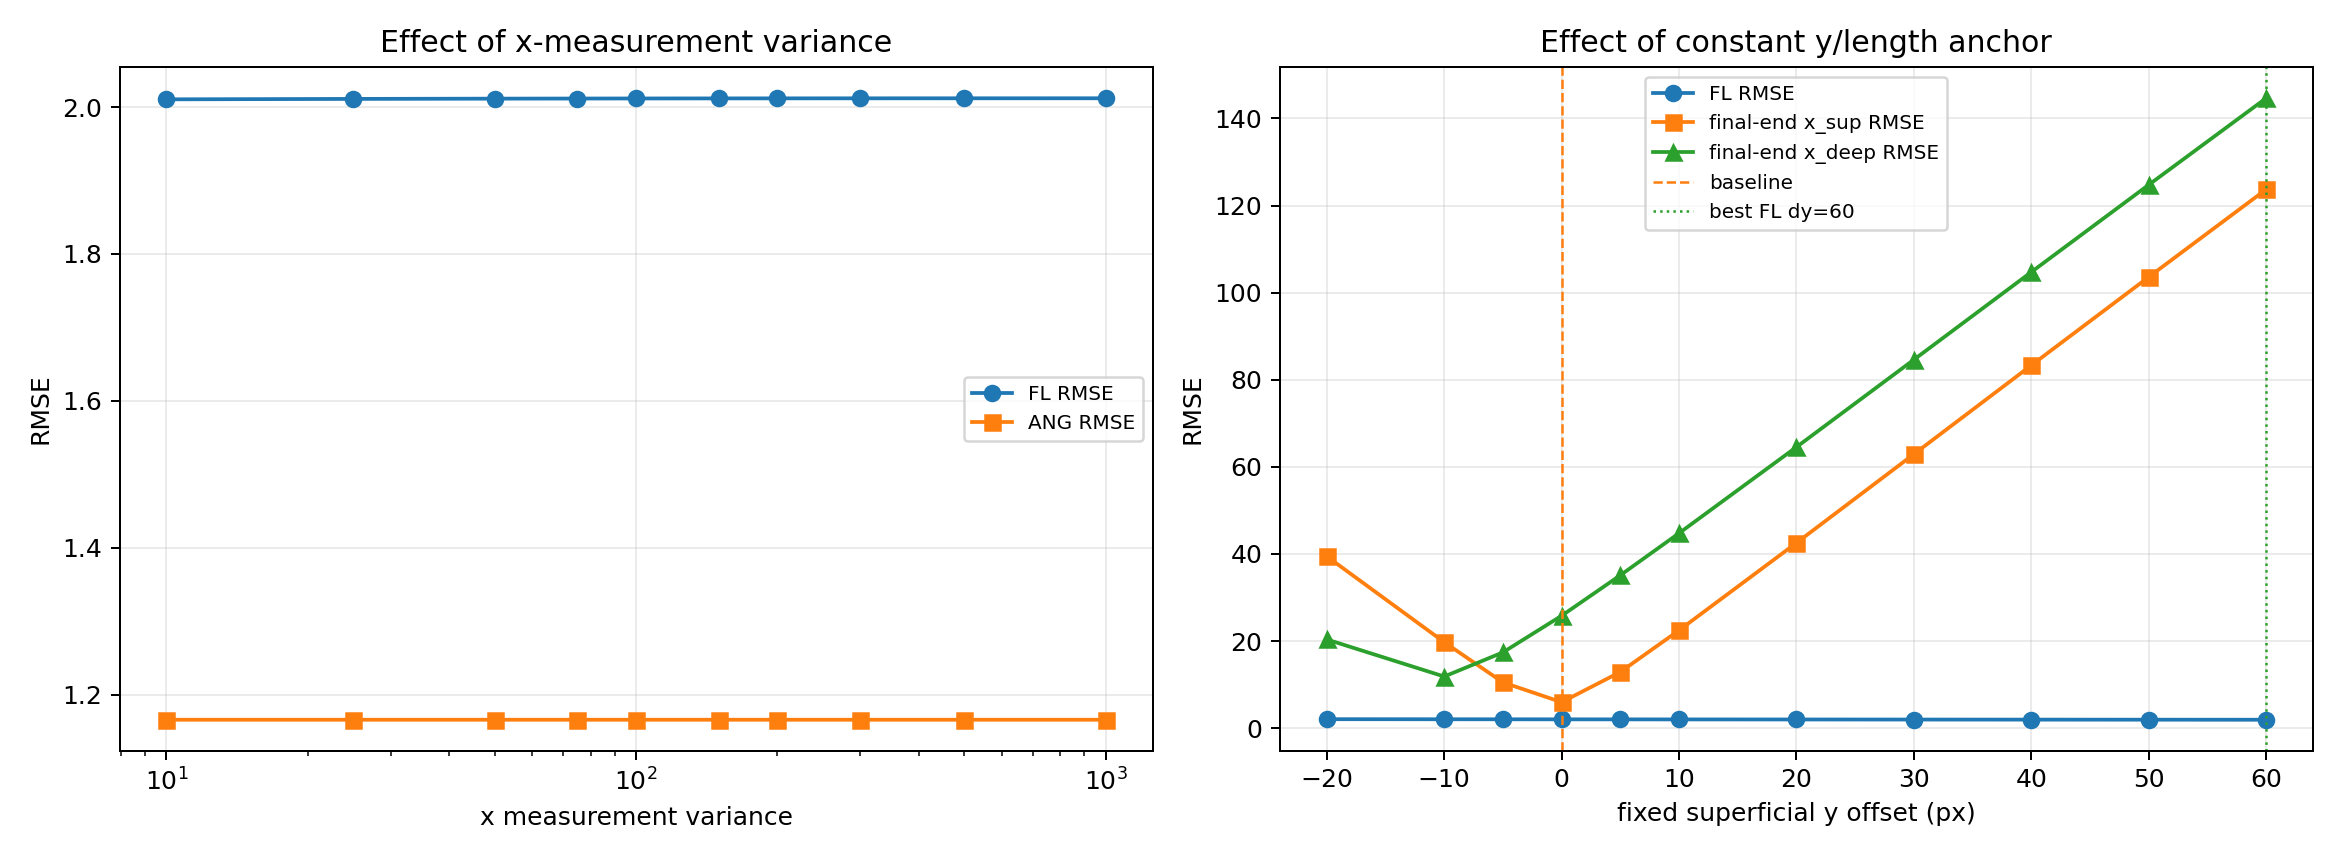

In [4]:
display(Markdown('## X/length anchor sweep plot'))
display(Image(filename=str(OUT / 'x_length_anchor_sweeps.png')))